In [17]:
import subprocess, os
print("JAVA_HOME =", os.environ.get("JAVA_HOME"))
print(subprocess.check_output(["java", "-version"], stderr=subprocess.STDOUT).decode())

JAVA_HOME = None
openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment Temurin-17.0.17+10 (build 17.0.17+10)
OpenJDK 64-Bit Server VM Temurin-17.0.17+10 (build 17.0.17+10, mixed mode, sharing)



In [19]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# 1. AVVIO DELLA SPARK SESSION

spark = (
    SparkSession.builder
        .appName("US_Accidents_Classification")
        .config("spark.driver.memory", "6g")
        .config("spark.executor.memory", "4g")
        .getOrCreate()
)

print(" Spark version:", spark.version)


# 2. CARICAMENTO DEL DATASET CLEANED

csv_path = "../us_accidents_cleaned2/cleanedUS.csv"

df = (
    spark.read
        .option("header", True)
        .option("inferSchema", True)
        .option("multiLine", False)
        .option("mode", "DROPMALFORMED")
        .csv(csv_path)
)

print("Righe:", df.count())
print("Colonne:", len(df.columns))
df.show(5, truncate=False)

# 3. SCHEMA DEL DATASET

df.printSchema()

 Spark version: 4.0.1


Righe: 7485236
Colonne: 39
+---------------+-----+-----+-----------+-----------------+---------+-------+--------+-------------------+-------------------+-----------------+-------------------+------------+----------------------------------------------------------------------------------------------------------------------------------+---------------+-----------+----------+--------------+--------------+--------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+----+---+-------+----+---------------+
|weather_grouped|State|Month|Humidity(%)|Precipitation(in)|ID       |Source |Severity|Start_Time         |End_Time           |Start_Lat        |Start_Lng          |Distance(mi)|Description                                                                                                                       |City           |County     |Timezone  |Temperature(F)|Visibility(mi)|Wind_Direction|Amenity|B

In [20]:
cols_to_drop = [
    "ID", "Description",
    "Start_Time", "End_Time",
    "Start_Lat", "Start_Lng"
]

df_clean = df.drop(*cols_to_drop)
print("Colonne rimosse:", cols_to_drop)

Colonne rimosse: ['ID', 'Description', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng']


In [21]:
from pyspark.sql.functions import col
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler

bool_cols = [
    "Amenity", "Bump", "Crossing", "Give_Way", "Junction",
    "No_Exit", "Railway", "Roundabout", "Station", "Stop",
    "Traffic_Calming", "Traffic_Signal", "Turning_Loop"
]

for c in bool_cols:
    if c in df_clean.columns:
        df_clean = df_clean.withColumn(c, col(c).cast("int"))


categorical_large = [
    "City", "County", "State", "Timezone",
    "Source", "weather_grouped", "Wind_Direction"
]

numeric_cols = [
    "Month", "Humidity(%)", "Precipitation(in)", "Distance(mi)",
    "Temperature(F)", "Visibility(mi)", "Wind_Speed(mph)",
    "Year", "Day", "Weekday", "Hour", "Sunrise_Sunset"
] + bool_cols

label_col = "Severity"

df_sample = df_clean.sample(fraction=0.4, seed=42).cache()

train_raw, val_raw, test_raw = df_sample.randomSplit(
    [0.7, 0.15, 0.15],
    seed=42
)

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_large
]


feature_cols = (
    numeric_cols +
    [f"{c}_idx" for c in categorical_large]
)

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features_raw",
    handleInvalid="keep"
)

scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=True
)

pipeline = Pipeline(stages=indexers + encoders + [assembler, scaler])

pipeline_model = pipeline.fit(train_raw)

train_df = pipeline_model.transform(train_raw)
val_df   = pipeline_model.transform(val_raw)
test_df  = pipeline_model.transform(test_raw)

print("Train:", train_df.count())
print("Val:", val_df.count())
print("Test:", test_df.count())


26/01/09 19:17:20 WARN CacheManager: Asked to cache already cached data.


Train: 2098404


Val: 449217


Test: 449289


In [44]:
train_df.select("features", "Severity").printSchema()


root
 |-- features: vector (nullable = true)
 |-- Severity: integer (nullable = true)



## DECISION TREE SBILANCIATO


Training Decision Tree…


Decision Tree completato



Decision Tree – Validation METRICS
Accuracy:  0.8276
F1-score:  0.8121
Precision: 0.8097
Recall:    0.8276



Decision Tree – Test METRICS
Accuracy:  0.8263
F1-score:  0.8106
Precision: 0.8084
Recall:    0.8263

CONFUSION MATRIX — Decision Tree (Test)


    Severity  prediction   count
0          1         1.0    1975
1          1         2.0    1641
2          1         3.0     325
3          1         4.0       8
4          2         1.0     925
5          2         2.0  333776
6          2         3.0   21577
7          2         4.0     736
8          3         1.0     575
9          3         2.0   41427
10         3         3.0   33966
11         3         4.0     406
12         4         1.0      10
13         4         2.0    9391
14         4         3.0    1017
15         4         4.0    1534


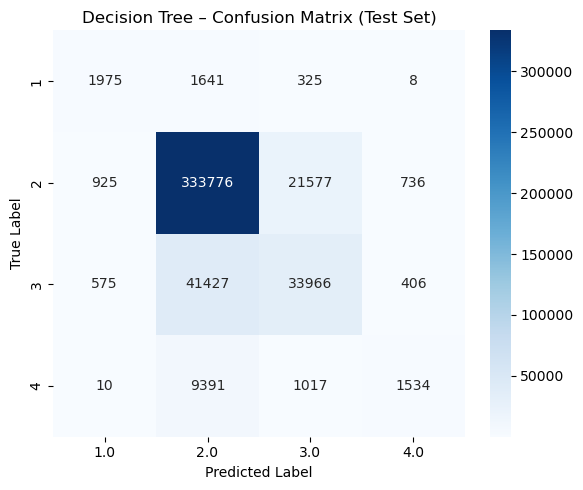

In [11]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# =====================================================
# DECISION TREE
# =====================================================
dt = DecisionTreeClassifier(
    labelCol="Severity",
    featuresCol="features",
    maxBins=32,
    seed=42
)

# =====================================================
# GRID
# =====================================================
paramGrid_dt = (
    ParamGridBuilder()
    .addGrid(dt.maxDepth, [5, 10])
    .addGrid(dt.impurity, ["gini", "entropy"])
    .build()
)

# =====================================================
# EVALUATOR
# =====================================================
evaluator = MulticlassClassificationEvaluator(
    labelCol="Severity",
    predictionCol="prediction",
    metricName="f1"
)

# =====================================================
# TRAIN-VALIDATION SPLIT (STABILE)
# =====================================================
tvs_dt = TrainValidationSplit(
    estimator=dt,
    estimatorParamMaps=paramGrid_dt,
    evaluator=evaluator,
    trainRatio=0.8,
    parallelism=1
)

# =====================================================
# TRAINING
# =====================================================
print("\nTraining Decision Tree…")
dt_model = tvs_dt.fit(train_df)
best_dt = dt_model.bestModel
print("Decision Tree completato")

# =====================================================
# METRICHE
# =====================================================
def metrics(df, name):
    acc = evaluator.setMetricName("accuracy").evaluate(df)
    f1 = evaluator.setMetricName("f1").evaluate(df)
    prec = evaluator.setMetricName("weightedPrecision").evaluate(df)
    rec = evaluator.setMetricName("weightedRecall").evaluate(df)

    print(f"\n{name} METRICS")
    print(f"Accuracy:  {acc:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")

# =====================================================
# VALUTAZIONE
# =====================================================
pred_val_dt = best_dt.transform(val_df)
pred_test_dt = best_dt.transform(test_df)

metrics(pred_val_dt, "Decision Tree – Validation")
metrics(pred_test_dt, "Decision Tree – Test")

# =====================================================
# CONFUSION MATRIX 
# =====================================================
print("\nCONFUSION MATRIX — Decision Tree (Test)")

cm_pd = (
    pred_test_dt
    .groupBy("Severity", "prediction")
    .count()
    .orderBy("Severity", "prediction")
    .toPandas()
)

print(cm_pd)

# =====================================================
# CONFUSION MATRIX HEATMAP (TEST SET)
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot to matrix form
cm_matrix = cm_pd.pivot(
    index="Severity",
    columns="prediction",
    values="count"
).fillna(0)

# Plot heatmap with clear colors
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    cbar=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()



## RANDOM FOREST SBILANCIATO


Training Random Forest…


26/01/09 11:03:59 WARN DAGScheduler: Broadcasting large task binary with size 1012.0 KiB
26/01/09 11:04:07 WARN DAGScheduler: Broadcasting large task binary with size 1188.2 KiB
26/01/09 11:04:18 WARN DAGScheduler: Broadcasting large task binary with size 1539.7 KiB
26/01/09 11:04:31 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/01/09 11:04:45 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/01/09 11:05:03 WARN DAGScheduler: Broadcasting large task binary with size 2.3 MiB
26/01/09 11:05:42 WARN DAGScheduler: Broadcasting large task binary with size 1012.0 KiB
26/01/09 11:05:50 WARN DAGScheduler: Broadcasting large task binary with size 1188.2 KiB
26/01/09 11:06:00 WARN DAGScheduler: Broadcasting large task binary with size 1539.7 KiB
26/01/09 11:06:12 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/01/09 11:06:30 WARN DAGScheduler: Broadcasting large task binary with size 3.5 MiB
26/01/09 11:06:47 WARN DAGScheduler:

[1563,041s][warning][gc,alloc] Executor task launch worker for task 8.0 in stage 417.0 (TID 6421): Retried waiting for GCLocker too often allocating 113359 words


26/01/09 11:09:34 WARN DAGScheduler: Broadcasting large task binary with size 7.4 MiB
26/01/09 11:09:43 WARN DAGScheduler: Broadcasting large task binary with size 20.6 MiB
26/01/09 11:10:27 WARN DAGScheduler: Broadcasting large task binary with size 1066.6 KiB
26/01/09 11:10:38 WARN DAGScheduler: Broadcasting large task binary with size 1301.1 KiB
26/01/09 11:10:52 WARN DAGScheduler: Broadcasting large task binary with size 1768.2 KiB
26/01/09 11:11:08 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
26/01/09 11:11:31 WARN DAGScheduler: Broadcasting large task binary with size 4.4 MiB
26/01/09 11:11:53 WARN DAGScheduler: Broadcasting large task binary with size 1096.8 KiB
26/01/09 11:11:55 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
26/01/09 11:12:34 WARN DAGScheduler: Broadcasting large task binary with size 1066.6 KiB
26/01/09 11:12:45 WARN DAGScheduler: Broadcasting large task binary with size 1301.1 KiB
26/01/09 11:12:58 WARN DAGScheduler

[2529,870s][warning][gc,alloc] Executor task launch worker for task 17.0 in stage 510.0 (TID 8116): Retried waiting for GCLocker too often allocating 137851 words


...


Random Forest – Validation METRICS
Accuracy:   0.8264
F1-score:   0.7873
Precision:  0.8135
Recall:     0.8264


26/01/09 11:28:46 WARN DAGScheduler: Broadcasting large task binary with size 27.7 MiB
26/01/09 11:29:07 WARN DAGScheduler: Broadcasting large task binary with size 27.7 MiB
26/01/09 11:29:27 WARN DAGScheduler: Broadcasting large task binary with size 27.7 MiB
26/01/09 11:29:45 WARN DAGScheduler: Broadcasting large task binary with size 27.7 MiB



Random Forest – Test METRICS
Accuracy:   0.8257
F1-score:   0.7864
Precision:  0.8127
Recall:     0.8257

CONFUSION MATRIX — Random Forest (Test)


26/01/09 11:30:03 WARN DAGScheduler: Broadcasting large task binary with size 27.7 MiB
26/01/09 11:30:21 WARN DAGScheduler: Broadcasting large task binary with size 27.6 MiB
26/01/09 11:30:22 WARN DAGScheduler: Broadcasting large task binary with size 27.6 MiB
26/01/09 11:30:24 WARN DAGScheduler: Broadcasting large task binary with size 27.6 MiB


    Severity  prediction   count
0          1         1.0     527
1          1         2.0    3357
2          1         3.0      65
3          2         1.0      51
4          2         2.0  349087
5          2         3.0    7801
6          2         4.0      75
7          3         1.0       8
8          3         2.0   55496
9          3         3.0   20819
10         3         4.0      51
11         4         1.0       2
12         4         2.0   10851
13         4         3.0     573
14         4         4.0     526


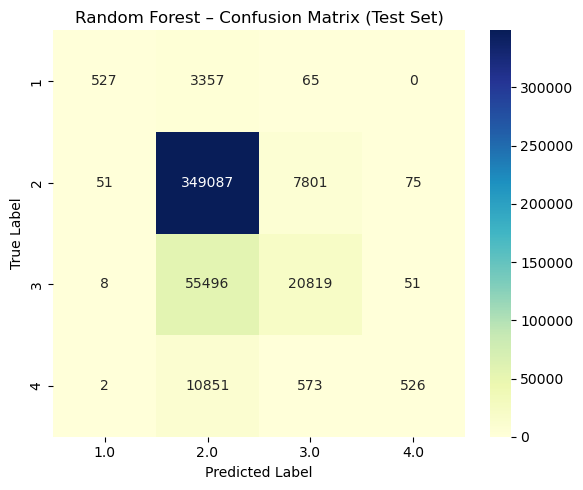

In [13]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

train_df = train_df.cache()
train_df.count()

rf = RandomForestClassifier(
    labelCol="Severity",
    featuresCol="features",
    maxBins=32,
    seed=42
)

paramGrid_rf = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [60, 80])
    .addGrid(rf.maxDepth, [8, 12])
    .build()
)

evaluator = MulticlassClassificationEvaluator(
    labelCol="Severity",
    predictionCol="prediction",
    metricName="f1"
)

tvs_rf = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=paramGrid_rf,
    evaluator=evaluator,
    trainRatio=0.8,
    parallelism=1
)

print("\nTraining Random Forest…")
rf_model = tvs_rf.fit(train_df)
best_rf = rf_model.bestModel
print("Random Forest completato")

def metrics(df, name):
    acc = evaluator.setMetricName("accuracy").evaluate(df)
    f1 = evaluator.setMetricName("f1").evaluate(df)
    prec = evaluator.setMetricName("weightedPrecision").evaluate(df)
    rec = evaluator.setMetricName("weightedRecall").evaluate(df)

    print(f"\n{name} METRICS")
    print(f"Accuracy:   {acc:.4f}")
    print(f"F1-score:   {f1:.4f}")
    print(f"Precision:  {prec:.4f}")
    print(f"Recall:     {rec:.4f}")

pred_val_rf = best_rf.transform(val_df)
pred_test_rf = best_rf.transform(test_df)

metrics(pred_val_rf, "Random Forest – Validation")
metrics(pred_test_rf, "Random Forest – Test")

# =====================================================
# CONFUSION MATRIX 
# =====================================================
print("\nCONFUSION MATRIX — Random Forest (Test)")

cm_pd = (
    pred_test_rf
    .groupBy("Severity", "prediction")
    .count()
    .orderBy("Severity", "prediction")
    .toPandas()
)

print(cm_pd)

# =====================================================
# CONFUSION MATRIX HEATMAP (TEST SET)
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot to matrix form
cm_matrix = cm_pd.pivot(
    index="Severity",
    columns="prediction",
    values="count"
).fillna(0)

# Plot heatmap (clear but different colors)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_matrix,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",   # chiaro e distinto dal DT
    cbar=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()



## LOGISTIC REGRESSION SBILANCIATO


Training Logistic Regression…


26/01/09 11:30:39 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Logistic Regression completata



Logistic Regression – Validation METRICS
Accuracy:   0.7990
F1-score:   0.7624
Precision:  0.7595
Recall:     0.7990



Logistic Regression – Test METRICS
Accuracy:   0.7981
F1-score:   0.7616
Precision:  0.7600
Recall:     0.7981

CONFUSION MATRIX — Logistic Regression (Test)


    Severity  prediction   count
0          1         1.0      10
1          1         2.0    3751
2          1         3.0     188
3          2         1.0       9
4          2         2.0  338533
5          2         3.0   17856
6          2         4.0     616
7          3         1.0       1
8          3         2.0   56849
9          3         3.0   19433
10         3         4.0      91
11         4         2.0   11171
12         4         3.0     175
13         4         4.0     606


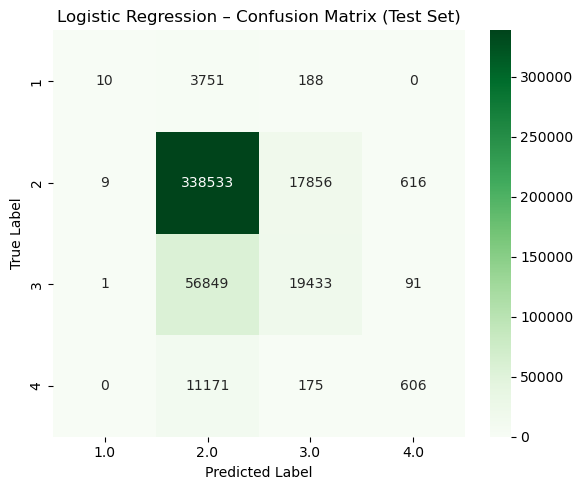

In [14]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# =====================================================
# MODELLO
# =====================================================
lr = LogisticRegression(
    labelCol="Severity",
    featuresCol="features",
    maxIter=50
)

# =====================================================
# GRID RIDOTTA E SENSATA
# =====================================================
paramGrid_lr = (
    ParamGridBuilder()
    .addGrid(lr.regParam, [0.0, 0.1])
    .addGrid(lr.elasticNetParam, [0.0, 1.0])
    .build()
)

# =====================================================
# EVALUATOR
# =====================================================
evaluator = MulticlassClassificationEvaluator(
    labelCol="Severity",
    predictionCol="prediction",
    metricName="f1"
)

# =====================================================
# TRAIN-VALIDATION SPLIT
# =====================================================
tvs_lr = TrainValidationSplit(
    estimator=lr,
    estimatorParamMaps=paramGrid_lr,
    evaluator=evaluator,
    trainRatio=0.8,
    parallelism=1
)

# =====================================================
# TRAINING
# =====================================================
print("\nTraining Logistic Regression…")
lr_model = tvs_lr.fit(train_df)
best_lr = lr_model.bestModel
print("Logistic Regression completata")

# =====================================================
# METRICHE
# =====================================================
def metrics(df, name):
    acc = evaluator.setMetricName("accuracy").evaluate(df)
    f1 = evaluator.setMetricName("f1").evaluate(df)
    prec = evaluator.setMetricName("weightedPrecision").evaluate(df)
    rec = evaluator.setMetricName("weightedRecall").evaluate(df)

    print(f"\n{name} METRICS")
    print(f"Accuracy:   {acc:.4f}")
    print(f"F1-score:   {f1:.4f}")
    print(f"Precision:  {prec:.4f}")
    print(f"Recall:     {rec:.4f}")

# =====================================================
# VALUTAZIONE
# =====================================================
pred_val_lr = best_lr.transform(val_df)
pred_test_lr = best_lr.transform(test_df)

metrics(pred_val_lr, "Logistic Regression – Validation")
metrics(pred_test_lr, "Logistic Regression – Test")

# =====================================================
# CONFUSION MATRIX 
# =====================================================
print("\nCONFUSION MATRIX — Logistic Regression (Test)")

cm_pd = (
    pred_test_lr
    .groupBy("Severity", "prediction")
    .count()
    .orderBy("Severity", "prediction")
    .toPandas()
)

print(cm_pd)

# =====================================================
# CONFUSION MATRIX HEATMAP (TEST SET)
# =====================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot to matrix form
cm_matrix = cm_pd.pivot(
    index="Severity",
    columns="prediction",
    values="count"
).fillna(0)

# Plot heatmap (clear but distinct colors)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_matrix,
    annot=True,
    fmt=".0f",
    cmap="Greens", 
    cbar=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression – Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()



## OVERSAMPLING 

In [22]:
# ============================
# OVERSAMPLING PROPORZIONALE LEGGERO
# ============================

counts = train_df.groupBy("Severity").count().toPandas()
max_count = counts["count"].max()

target_minor = int(max_count * 0.6)  # 60% della classe dominante

df_list = []

for idx, row in counts.iterrows():
    sev = row["Severity"]
    cnt = row["count"]

    df_class = train_df.filter(F.col("Severity") == sev)

    if cnt < target_minor:
        frac = target_minor / cnt
        df_oversampled = df_class.sample(withReplacement=True, fraction=frac, seed=42)
        df_list.append(df_oversampled)
    else:
        df_list.append(df_class)

df_balanced_over = df_list[0]
for df in df_list[1:]:
    df_balanced_over = df_balanced_over.unionByName(df)

print("Final size after light oversampling:", df_balanced_over.count())

Final size after light oversampling: 4668434


## UNDERSAMPLING

In [23]:
# ============================
# UNDERSAMPLING CONTROLLATO
# ============================

from pyspark.sql import functions as F

# 1. Conteggio classi
counts = train_df.groupBy("Severity").count().toPandas()
minor_sizes = counts[counts["Severity"] != counts["count"].idxmax()]["count"]
avg_minor = minor_sizes.mean()

target_size = int(avg_minor * 1.2)  # 20% più grande della media minoritarie

print("Target size for largest class:", target_size)

# 2. Dividiamo classi
major_class = counts.loc[counts["count"].idxmax(), "Severity"]

df_major = train_df.filter(F.col("Severity") == major_class)
df_minor = train_df.filter(F.col("Severity") != major_class)

# 3. Undersampling controllato
df_major_sampled = df_major.sample(
    withReplacement=False,
    fraction=min(1.0, target_size / df_major.count()),
    seed=42
)

df_balanced_under = df_major_sampled.unionByName(df_minor)

print("Final size after controlled undersampling:", df_balanced_under.count())

Target size for largest class: 696423


Final size after controlled undersampling: 1127970


## DT BILANCIATO

26/01/09 19:49:43 WARN DAGScheduler: Broadcasting large task binary with size 1096.8 KiB
26/01/09 19:49:43 WARN DAGScheduler: Broadcasting large task binary with size 1096.7 KiB
26/01/09 19:50:31 WARN DAGScheduler: Broadcasting large task binary with size 1101.6 KiB
26/01/09 19:51:18 WARN DAGScheduler: Broadcasting large task binary with size 1104.2 KiB
26/01/09 19:52:21 WARN DAGScheduler: Broadcasting large task binary with size 1105.0 KiB
26/01/09 19:52:23 WARN DAGScheduler: Broadcasting large task binary with size 1106.1 KiB
26/01/09 19:52:24 WARN DAGScheduler: Broadcasting large task binary with size 1107.1 KiB
26/01/09 19:52:25 WARN DAGScheduler: Broadcasting large task binary with size 1109.7 KiB
26/01/09 19:52:27 WARN DAGScheduler: Broadcasting large task binary with size 1115.2 KiB
26/01/09 19:52:29 WARN DAGScheduler: Broadcasting large task binary with size 1126.2 KiB
26/01/09 19:52:31 WARN DAGScheduler: Broadcasting large task binary with size 1147.9 KiB
26/01/09 19:52:33 WAR


===== DT (Oversampling) — Test =====


accuracy: 0.6996


f1: 0.7420


weightedPrecision: 0.8450


weightedRecall: 0.6996


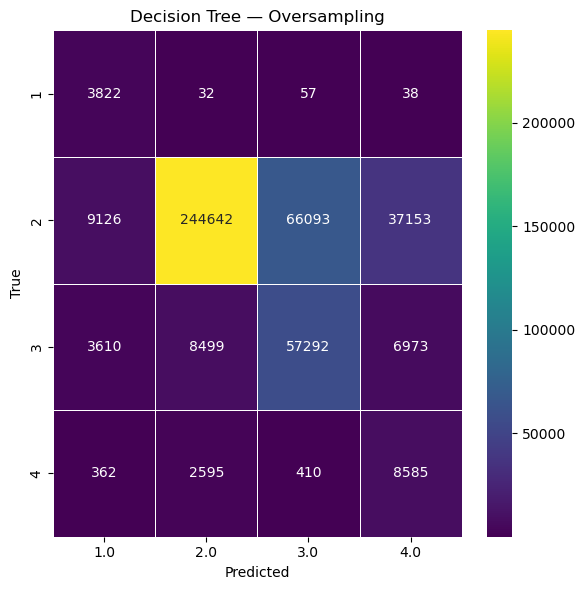


===== FEATURE IMPORTANCE (TOP 25) =====
Distance(mi)                   → 0.3331
Year                           → 0.2994
Source_idx                     → 0.1642
Month                          → 0.0596
State_idx                      → 0.0452
County_idx                     → 0.0231
Traffic_Signal                 → 0.0222
City_idx                       → 0.0151
Timezone_idx                   → 0.0094
Hour                           → 0.0083
Day                            → 0.0045
Crossing                       → 0.0043
Weekday                        → 0.0042
Stop                           → 0.0035
Junction                       → 0.0014
Sunrise_Sunset_ohe             → 0.0007
Temperature(F)                 → 0.0006
Wind_Speed(mph)                → 0.0003
Humidity(%)                    → 0.0003
Wind_Direction_idx             → 0.0002
weather_grouped_idx            → 0.0001
Railway                        → 0.0001
Give_Way                       → 0.0001
Precipitation(in)              → 0.0001

26/01/09 19:54:17 WARN DAGScheduler: Broadcasting large task binary with size 1062.8 KiB



===== DT (Undersampling) — Test =====


accuracy: 0.7937


f1: 0.8037


weightedPrecision: 0.8273


weightedRecall: 0.7937


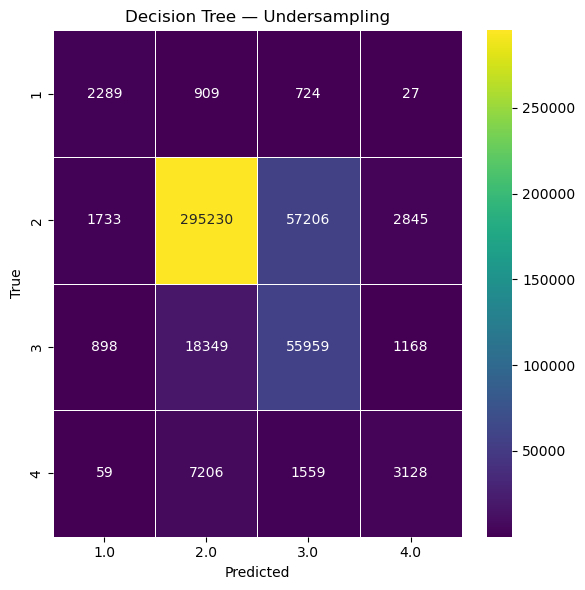


===== FEATURE IMPORTANCE (TOP 25) =====
Source_idx                     → 0.3893
Year                           → 0.2570
Traffic_Signal                 → 0.0753
State_idx                      → 0.0566
Month                          → 0.0565
Distance(mi)                   → 0.0520
City_idx                       → 0.0196
County_idx                     → 0.0191
Crossing                       → 0.0172
Hour                           → 0.0171
Stop                           → 0.0118
Timezone_idx                   → 0.0098
Weekday                        → 0.0083
Humidity(%)                    → 0.0034
Day                            → 0.0019
Sunrise_Sunset_ohe             → 0.0015
Junction                       → 0.0011
Temperature(F)                 → 0.0008
Give_Way                       → 0.0004
Wind_Speed(mph)                → 0.0002
Station                        → 0.0002
weather_grouped_idx            → 0.0001
Precipitation(in)              → 0.0001
Wind_Direction_idx             → 0.0001

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# ============================
# FUNZIONI
# ============================

evaluator = MulticlassClassificationEvaluator(
    labelCol="Severity", predictionCol="prediction", metricName="f1"
)

def compute_metrics(pred, name):
    print(f"\n===== {name} =====")
    for metric in ["accuracy", "f1", "weightedPrecision", "weightedRecall"]:
        evaluator.setMetricName(metric)
        print(f"{metric}: {evaluator.evaluate(pred):.4f}")

def plot_cm(pred, title):
    pdf = pred.groupBy("Severity", "prediction").count().toPandas()
    cm = pdf.pivot(index="Severity", columns="prediction", values="count").fillna(0)

    plt.figure(figsize=(6,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".0f",
        cmap="viridis",
        linewidths=0.5,
        linecolor="white"
    )
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


def feature_importance(model, pipeline_model):
    for st in pipeline_model.stages:
        if st.__class__.__name__ == "VectorAssembler":
            assembler = st
            break
    names = assembler.getInputCols()
    scores = model.featureImportances.toArray()

    print("\n===== FEATURE IMPORTANCE (TOP 25) =====")
    for n, s in sorted(zip(names, scores), key=lambda x:-x[1])[:25]:
        print(f"{n:30} → {s:.4f}")

# ============================
# DECISION TREE Training Function
# ============================

def train_dt(dataset, name):
    dt = DecisionTreeClassifier(
        labelCol="Severity", featuresCol="features",
        maxDepth=10, impurity="entropy"
    )

    model = dt.fit(dataset)
    pred_val  = model.transform(val_df)
    pred_test = model.transform(test_df)

    compute_metrics(pred_test, f"DT ({name}) — Test")
    plot_cm(pred_test, f"Decision Tree — {name}")
    feature_importance(model, pipeline_model)

    return model

# ============================
# ESECUZIONE
# ============================

dt_over_model = train_dt(df_balanced_over,  "Oversampling")
dt_under_model = train_dt(df_balanced_under, "Undersampling")

## LOGISTIC REGRESSION BILANCIATO

26/01/07 12:37:13 WARN DAGScheduler: Broadcasting large task binary with size 1099.2 KiB
26/01/07 12:38:00 WARN DAGScheduler: Broadcasting large task binary with size 1100.3 KiB
26/01/07 12:38:01 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/01/07 12:38:01 WARN DAGScheduler: Broadcasting large task binary with size 1099.3 KiB
26/01/07 12:39:12 WARN DAGScheduler: Broadcasting large task binary with size 1100.5 KiB
26/01/07 12:39:12 WARN DAGScheduler: Broadcasting large task binary with size 1099.3 KiB
26/01/07 12:39:15 WARN DAGScheduler: Broadcasting large task binary with size 1100.5 KiB
26/01/07 12:39:15 WARN DAGScheduler: Broadcasting large task binary with size 1099.3 KiB
26/01/07 12:39:17 WARN DAGScheduler: Broadcasting large task binary with size 1100.5 KiB
26/01/07 12:39:17 WARN DAGScheduler: Broadcasting large task binary with size 1099.3 KiB
26/01/07 12:39:19 WARN DAGScheduler: Broadcasting large task binary with size 1100.5 KiB
26/


===== LR (Oversampling) — Test =====


accuracy: 0.5822


f1: 0.6487


weightedPrecision: 0.8008


weightedRecall: 0.5822


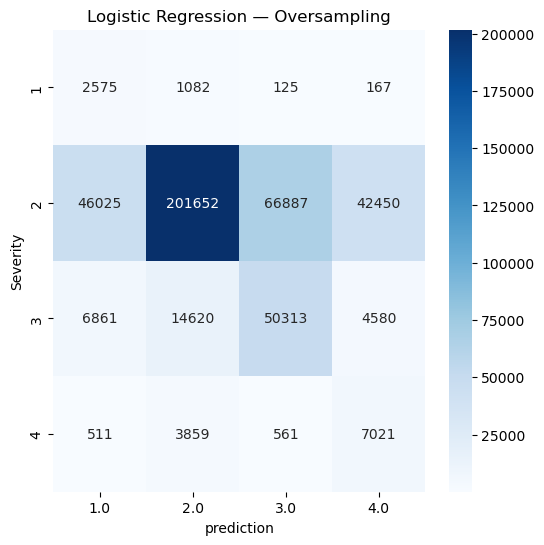


===== LR (Undersampling) — Test =====


accuracy: 0.7693


f1: 0.7730


weightedPrecision: 0.7926


weightedRecall: 0.7693


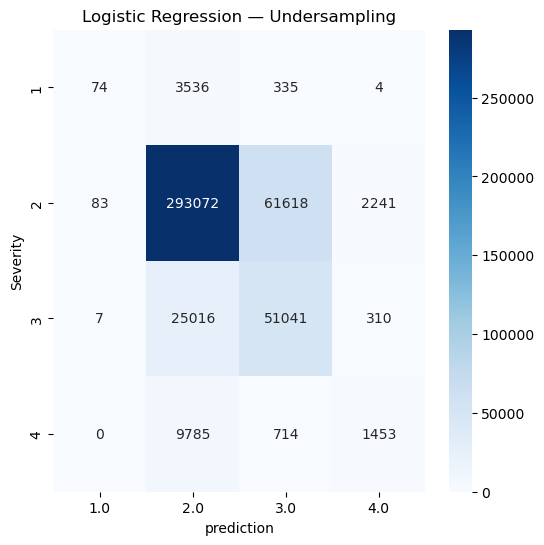

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# ============================
# FUNZIONI METRICHE + CONFUSION MATRIX
# ============================

evaluator = MulticlassClassificationEvaluator(
    labelCol="Severity", predictionCol="prediction", metricName="f1"
)

def compute_metrics(pred, name):
    print(f"\n===== {name} =====")
    for m in ["accuracy","f1","weightedPrecision","weightedRecall"]:
        evaluator.setMetricName(m)
        print(f"{m}: {evaluator.evaluate(pred):.4f}")

def plot_cm(pred, title):
    pdf = pred.groupBy("Severity", "prediction").count().toPandas()
    cm = pdf.pivot(index="Severity", columns="prediction", values="count").fillna(0)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues")
    plt.title(title)
    plt.show()

# ============================
# LOGISTIC REGRESSION Training
# ============================

def train_lr(dataset, name):
    lr = LogisticRegression(
        labelCol="Severity",
        featuresCol="features",
        maxIter=50
    )

    model = lr.fit(dataset)
    pred_test = model.transform(test_df)

    compute_metrics(pred_test, f"LR ({name}) — Test")
    plot_cm(pred_test, f"Logistic Regression — {name}")

# ============================
# ESECUZIONE
# ============================

train_lr(df_balanced_over,  "Oversampling")
train_lr(df_balanced_under, "Undersampling")

## RANDOM FOREST BILANCIATO

26/01/09 20:28:07 WARN DAGScheduler: Broadcasting large task binary with size 1096.9 KiB
26/01/09 20:28:07 WARN DAGScheduler: Broadcasting large task binary with size 1096.8 KiB
26/01/09 20:28:59 WARN DAGScheduler: Broadcasting large task binary with size 1101.7 KiB
26/01/09 20:29:44 WARN DAGScheduler: Broadcasting large task binary with size 1110.7 KiB
26/01/09 20:30:41 WARN DAGScheduler: Broadcasting large task binary with size 1134.8 KiB
26/01/09 20:30:55 WARN DAGScheduler: Broadcasting large task binary with size 1178.9 KiB
26/01/09 20:31:12 WARN DAGScheduler: Broadcasting large task binary with size 1269.6 KiB
26/01/09 20:31:31 WARN DAGScheduler: Broadcasting large task binary with size 1446.8 KiB
26/01/09 20:31:52 WARN DAGScheduler: Broadcasting large task binary with size 1800.8 KiB
26/01/09 20:32:16 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/01/09 20:32:42 WARN DAGScheduler: Broadcasting large task binary with size 3.8 MiB
26/01/09 20:33:17 WARN DAGS


===== RF (Oversampling) — Test =====


26/01/09 20:38:59 WARN DAGScheduler: Broadcasting large task binary with size 27.4 MiB


accuracy: 0.6825


26/01/09 20:39:11 WARN DAGScheduler: Broadcasting large task binary with size 27.4 MiB


...

26/01/09 20:39:20 WARN DAGScheduler: Broadcasting large task binary with size 27.4 MiB


weightedPrecision: 0.8494


26/01/09 20:39:28 WARN DAGScheduler: Broadcasting large task binary with size 27.4 MiB


weightedRecall: 0.6825


26/01/09 20:39:37 WARN DAGScheduler: Broadcasting large task binary with size 27.4 MiB
26/01/09 20:39:46 WARN DAGScheduler: Broadcasting large task binary with size 27.3 MiB


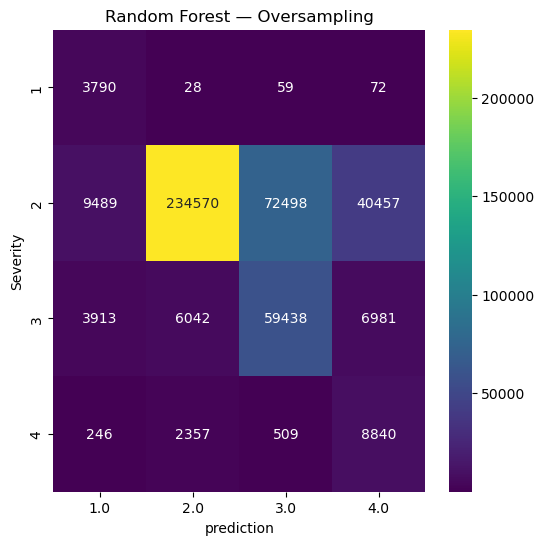


===== FEATURE IMPORTANCE (TOP 25) =====
Year                           → 0.2627
Distance(mi)                   → 0.2057
Source_idx                     → 0.1657
Month                          → 0.0694
County_idx                     → 0.0544
State_idx                      → 0.0399
City_idx                       → 0.0367
Traffic_Signal                 → 0.0357
Temperature(F)                 → 0.0208
Precipitation(in)              → 0.0204
Hour                           → 0.0189
Crossing                       → 0.0174
Timezone_idx                   → 0.0153
Weekday                        → 0.0061
Humidity(%)                    → 0.0054
Wind_Speed(mph)                → 0.0044
Stop                           → 0.0043
Day                            → 0.0030
Sunrise_Sunset_ohe             → 0.0027
Junction                       → 0.0026
weather_grouped_idx            → 0.0019
Wind_Direction_idx             → 0.0011
Visibility(mi)                 → 0.0008
Station                        → 0.0007

26/01/09 20:40:31 WARN DAGScheduler: Broadcasting large task binary with size 1060.0 KiB
26/01/09 20:40:34 WARN DAGScheduler: Broadcasting large task binary with size 1236.7 KiB
26/01/09 20:40:37 WARN DAGScheduler: Broadcasting large task binary with size 1589.6 KiB
26/01/09 20:40:42 WARN DAGScheduler: Broadcasting large task binary with size 2.2 MiB
26/01/09 20:40:49 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
26/01/09 20:40:58 WARN DAGScheduler: Broadcasting large task binary with size 6.2 MiB
26/01/09 20:41:07 WARN DAGScheduler: Broadcasting large task binary with size 1534.2 KiB
26/01/09 20:41:09 WARN DAGScheduler: Broadcasting large task binary with size 10.9 MiB
26/01/09 20:41:23 WARN DAGScheduler: Broadcasting large task binary with size 2.7 MiB
26/01/09 20:41:26 WARN DAGScheduler: Broadcasting large task binary with size 19.2 MiB
26/01/09 20:41:45 WARN DAGScheduler: Broadcasting large task binary with size 4.5 MiB
26/01/09 20:41:51 WARN DAGScheduler: Bro


===== RF (Undersampling) — Test =====


26/01/09 20:42:35 WARN DAGScheduler: Broadcasting large task binary with size 22.1 MiB


accuracy: 0.7890


...

26/01/09 20:42:51 WARN DAGScheduler: Broadcasting large task binary with size 22.1 MiB


weightedPrecision: 0.8373


26/01/09 20:42:59 WARN DAGScheduler: Broadcasting large task binary with size 22.1 MiB


weightedRecall: 0.7890


26/01/09 20:43:06 WARN DAGScheduler: Broadcasting large task binary with size 22.1 MiB
26/01/09 20:43:14 WARN DAGScheduler: Broadcasting large task binary with size 22.0 MiB


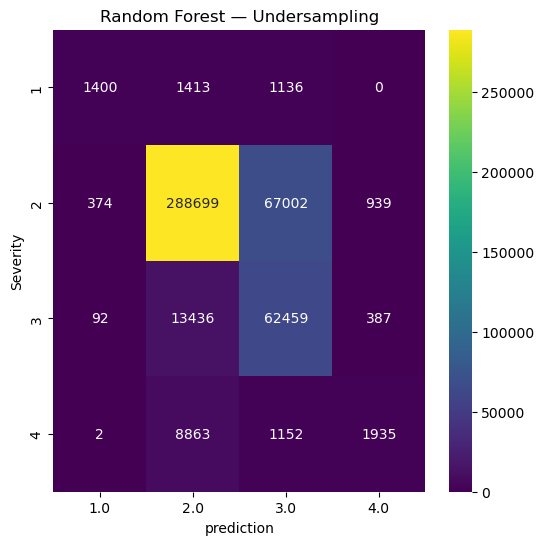


===== FEATURE IMPORTANCE (TOP 25) =====
Source_idx                     → 0.3243
Year                           → 0.1734
Distance(mi)                   → 0.1454
Traffic_Signal                 → 0.0739
State_idx                      → 0.0460
Crossing                       → 0.0427
County_idx                     → 0.0306
Precipitation(in)              → 0.0256
City_idx                       → 0.0232
Month                          → 0.0193
Hour                           → 0.0158
Timezone_idx                   → 0.0147
Stop                           → 0.0147
Wind_Speed(mph)                → 0.0103
Weekday                        → 0.0088
Junction                       → 0.0062
Temperature(F)                 → 0.0056
Humidity(%)                    → 0.0040
Station                        → 0.0029
weather_grouped_idx            → 0.0027
Amenity                        → 0.0017
Day                            → 0.0017
Sunrise_Sunset_ohe             → 0.0015
Wind_Direction_idx             → 0.0012

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# ============================
# FUNZIONI
# ============================

evaluator = MulticlassClassificationEvaluator(
    labelCol="Severity", predictionCol="prediction", metricName="f1"
)

def compute_metrics(pred, name):
    print(f"\n===== {name} =====")
    for m in ["accuracy","f1","weightedPrecision","weightedRecall"]:
        evaluator.setMetricName(m)
        print(f"{m}: {evaluator.evaluate(pred):.4f}")

def plot_cm(pred, title):
    pdf = pred.groupBy("Severity", "prediction").count().toPandas()
    cm = pdf.pivot(index="Severity", columns="prediction", values="count").fillna(0)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt=".0f", cmap="viridis")
    plt.title(title)
    plt.show()

def feature_importance(model, pipeline_model):
    for st in pipeline_model.stages:
        if st.__class__.__name__ == "VectorAssembler":
            assembler = st
            break
    names = assembler.getInputCols()
    scores = model.featureImportances.toArray()

    print("\n===== FEATURE IMPORTANCE (TOP 25) =====")
    for n, s in sorted(zip(names, scores), key=lambda x:-x[1])[:25]:
        print(f"{n:30} → {s:.4f}")

# ============================
# RANDOM FOREST Training
# ============================

def train_rf(dataset, name):
    rf = RandomForestClassifier(
        labelCol="Severity",
        featuresCol="features",
        numTrees=60,
        maxDepth=12,
        seed=42
    )

    model = rf.fit(dataset)
    pred_test = model.transform(test_df)

    compute_metrics(pred_test, f"RF ({name}) — Test")
    plot_cm(pred_test, f"Random Forest — {name}")
    feature_importance(model, pipeline_model)

# ============================
# ESECUZIONE
# ============================

train_rf(df_balanced_over,  "Oversampling")
train_rf(df_balanced_under, "Undersampling")